In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

# Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Save model
import joblib

In [2]:
df = pd.read_csv("Housing.csv")

df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

print("\nStatistical Summary:")
print(df.describe())

Shape: (4600, 18)

Columns:
Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')

Missing Values:
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

Data Types:
date              object
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
sqft_above         int64
sqft_basement      int64
yr_built           int

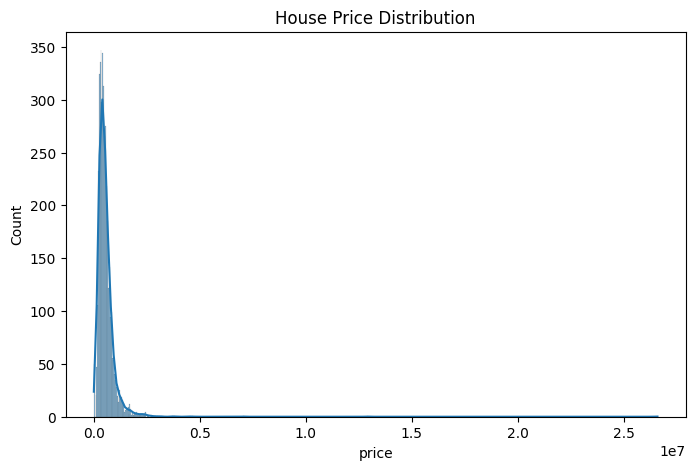

In [4]:
plt.figure(figsize=(8,5))

sns.histplot(df['price'], kde=True)

plt.title("House Price Distribution")

plt.show()

In [7]:
df['price'] = np.log1p(df['price'])

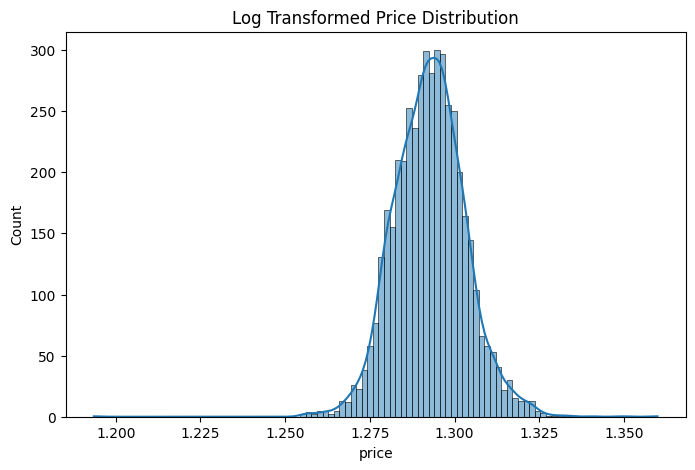

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df['price'], kde=True)

plt.title("Log Transformed Price Distribution")

plt.show()

In [15]:
# Remove rows with missing price values

df = df.dropna(subset=['price'])

In [16]:
categorical_cols = df.select_dtypes(include=['object']).columns

print(categorical_cols)

Index([], dtype='object')


In [17]:
df = pd.get_dummies(df, drop_first=True)

In [18]:
X = df.drop('price', axis=1)

y = df['price']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [21]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [22]:
rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [23]:
gb = GradientBoostingRegressor(random_state=42)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

In [24]:
def evaluate_model(name, y_test, predictions):

    mae = mean_absolute_error(y_test, predictions)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    r2 = r2_score(y_test, predictions)

    print(f"\n{name} Results")
    print("-" * 30)

    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2 Score:", r2)

In [25]:
evaluate_model("Linear Regression", y_test, lr_pred)

evaluate_model("Random Forest", y_test, rf_pred)

evaluate_model("Gradient Boosting", y_test, gb_pred)


Linear Regression Results
------------------------------
MAE: 0.005441268571891916
RMSE: 0.0073702757623031025
R2 Score: 0.507288763795934

Random Forest Results
------------------------------
MAE: 0.0036069093210280216
RMSE: 0.005453105180744643
R2 Score: 0.7302802549461449

Gradient Boosting Results
------------------------------
MAE: 0.003753391893380682
RMSE: 0.00549151296255694
R2 Score: 0.7264674478708046


In [26]:
residuals = y_test - gb_pred

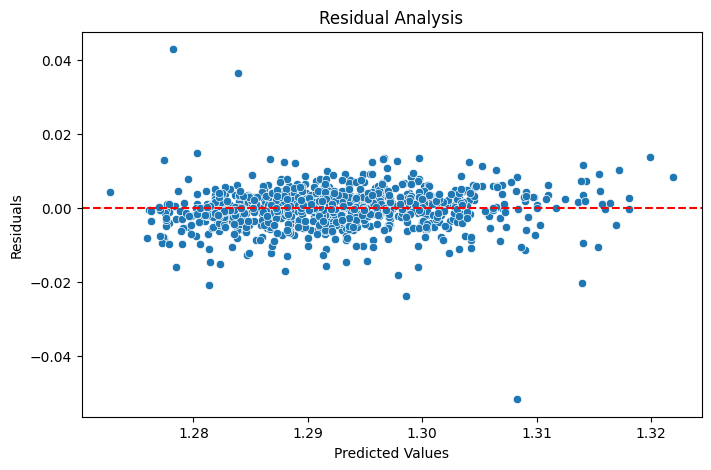

In [27]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=gb_pred, y=residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Values")

plt.ylabel("Residuals")

plt.title("Residual Analysis")

plt.show()

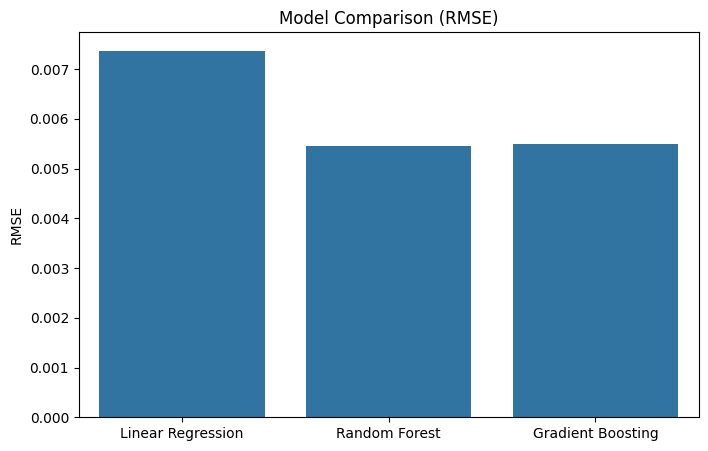

In [28]:
models = ['Linear Regression', 'Random Forest', 'Gradient Boosting']

rmse_values = [
    np.sqrt(mean_squared_error(y_test, lr_pred)),
    np.sqrt(mean_squared_error(y_test, rf_pred)),
    np.sqrt(mean_squared_error(y_test, gb_pred))
]

plt.figure(figsize=(8,5))

sns.barplot(x=models, y=rmse_values)

plt.title("Model Comparison (RMSE)")

plt.ylabel("RMSE")

plt.show()

In [29]:
joblib.dump(gb, 'best_house_price_model.pkl')

['best_house_price_model.pkl']

In [31]:
sample_house = pd.DataFrame(
    [X.iloc[0]],
    columns=X.columns
)

sample_house_scaled = scaler.transform(sample_house)

prediction = gb.predict(sample_house_scaled)

print("Predicted House Price:", np.exp(prediction[0]))

Predicted House Price: 3.6114022528181526
